### Setup

In [1]:
!nvidia-smi

Sun May 24 21:56:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
REPO_URL="https://github.com/ez3nx/itmo-speech-rec.git"
!git clone "$REPO_URL"

In [8]:
%cd /content/itmo-speech-rec//hw1-dsp
!ls -la

/content/itmo-speech-rec/hw1-dsp
total 12
drwxr-xr-x 2 root root 4096 May 24 21:57 .
drwxr-xr-x 4 root root 4096 May 24 21:57 ..
-rw-r--r-- 1 root root 3575 May 24 21:57 melbanks.py


In [23]:
import json
import random
import time
from pathlib import Path

import torch
import torchaudio
import matplotlib.pyplot as plt
import pandas as pd

from melbanks import LogMelFilterBanks # из 1-й части дз

print("Torch:", torch.__version__)
print("Torchaudio:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128
Torchaudio: 2.10.0+cu128
CUDA available: True


Quick check

In [10]:
signal = torch.randn(1, 16000)  # 1 second dummy waveform

melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)

logmelbanks = LogMelFilterBanks()(signal)

print("Shape equal:", torch.log(melspec + 1e-6).shape == logmelbanks.shape)
print("Allclose:", torch.allclose(torch.log(melspec + 1e-6), logmelbanks))

Shape equal: True
Allclose: True


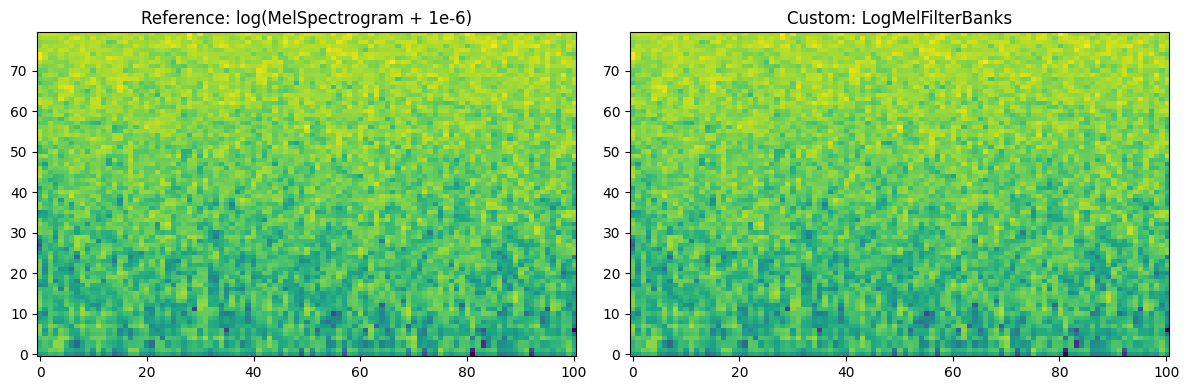

In [11]:
with torch.no_grad():
    ref = torch.log(melspec + 1e-6).squeeze(0).cpu().numpy()
    ours = logmelbanks.squeeze(0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(ref, origin="lower", aspect="auto")
ax[0].set_title("Reference: log(MelSpectrogram + 1e-6)")
ax[1].imshow(ours, origin="lower", aspect="auto")
ax[1].set_title("Custom: LogMelFilterBanks")
plt.tight_layout()
plt.show()

### Baseline training

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchaudio.datasets import SPEECHCOMMANDS

In [13]:
# Фиксируем сид для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Выбираем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# по условию задачи
TARGET_CLASSES = ["yes", "no"]
TARGET_SR = 16000
MAX_AUDIO_LEN = 16000  # 1 секунда

Напишем кастомный класс Dataset

In [31]:
class SpeechCommandsYesNo(Dataset):
    """
    Обертка над SPEECHCOMMANDS:
    - оставляет только yes/no
    - приводит длину к 1 секунде (pad/crop)
    """
    def __init__(self, subset="training", root="./data"):
        self.base = SPEECHCOMMANDS(root=root, download=True, subset=subset)
        self.indices = []
        self.targets = []

        for i, relpath in enumerate(self.base._walker):
            label = Path(relpath).parent.name.lower()
            if label in TARGET_CLASSES:
                self.indices.append(i)
                self.targets.append(TARGET_CLASSES.index(label))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        waveform, sr, label, *_ = self.base[self.indices[idx]]

        # На всякий случай проверяем sample rate
        if sr != TARGET_SR:
            waveform = torchaudio.functional.resample(waveform, sr, TARGET_SR)

        # waveform shape: (1, time) -> делаем ровно 16000
        if waveform.shape[1] < MAX_AUDIO_LEN:
            waveform = F.pad(waveform, (0, MAX_AUDIO_LEN - waveform.shape[1]))
        else:
            waveform = waveform[:, :MAX_AUDIO_LEN]

        y = self.targets[idx]
        return waveform.squeeze(0), y

Соберем простую модель на базе CNN

In [16]:
class SimpleConv1D(nn.Module):
    """
    Простая Conv1d-модель для бинарной классификации.
    Поддерживает параметр groups.
    """
    def __init__(self, n_mels=80, groups=1):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_mels, 32, kernel_size=5, padding=2, groups=groups),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, padding=1, groups=groups),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)       # (B, 64, 1)
        x = x.squeeze(-1)          # (B, 64)
        return self.classifier(x)  # (B, 2)

Хэлперы:

In [19]:
# !pip install thop

In [33]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def estimate_flops(model, n_mels=80, n_frames=101):
    import copy
    try:
        from thop import profile
        dummy = torch.randn(1, n_mels, n_frames)
        model_for_flops = copy.deepcopy(model).cpu().eval()  # копия на CPU
        flops, _ = profile(model_for_flops, inputs=(dummy,), verbose=False)
        return int(flops)
    except Exception:
        return None

Train-eval

In [21]:
@torch.no_grad()
def evaluate(model, mel_layer, loader, device):
    model.eval()
    mel_layer.eval()
    correct, total = 0, 0

    for waveforms, labels in loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)

        feats = mel_layer(waveforms)      # (B, n_mels, frames)
        logits = model(feats)             # (B, 2)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.numel()

    return correct / total if total > 0 else 0.0

In [22]:
def run_experiment(
    n_mels=80,
    groups=1,
    epochs=10,
    batch_size=128,
    lr=1e-3,
    num_workers=2,
    data_root="./data",
):
    print("=" * 70)
    print(f"Experiment: n_mels={n_mels}, groups={groups}, device={device}")
    print("=" * 70)

    # 1) Датасеты
    train_ds = SpeechCommandsYesNo("training", root=data_root)
    val_ds   = SpeechCommandsYesNo("validation", root=data_root)
    test_ds  = SpeechCommandsYesNo("testing", root=data_root)
    print(f"Sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=(device.type=="cuda"))
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=(device.type=="cuda"))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=(device.type=="cuda"))

    # 2) Слой признаков + модель
    mel_layer = LogMelFilterBanks(n_mels=n_mels).to(device)
    model = SimpleConv1D(n_mels=n_mels, groups=groups).to(device)

    # Проверка лимита параметров
    params = count_params(model)
    if params > 100_000:
        raise RuntimeError(f"Params limit exceeded: {params} > 100000")
    flops = estimate_flops(model, n_mels=n_mels, n_frames=101)

    print(f"Params: {params:,}")
    print(f"FLOPs: {flops if flops is not None else 'N/A (install thop)'}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "n_mels": n_mels,
        "groups": groups,
        "params": params,
        "flops": flops,
        "train_loss": [],
        "val_acc": [],
        "epoch_time_sec": [],
    }

    # 3) Цикл обучения
    for epoch in range(1, epochs + 1):
        model.train()
        mel_layer.eval()  # фичи не обучаем
        t0 = time.time()
        running_loss = 0.0

        for waveforms, labels in train_loader:
            waveforms = waveforms.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                feats = mel_layer(waveforms)

            optimizer.zero_grad()
            logits = model(feats)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)

        train_loss = running_loss / len(train_ds)
        val_acc = evaluate(model, mel_layer, val_loader, device)
        dt = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time_sec"].append(dt)

        print(f"Epoch {epoch:02d}/{epochs} | loss={train_loss:.4f} | val_acc={val_acc:.4f} | time={dt:.2f}s")

    # 4) Финальная оценка на test
    test_acc = evaluate(model, mel_layer, test_loader, device)
    history["test_acc"] = test_acc
    print(f"Test accuracy: {test_acc:.4f}")

    return history

Dir for saving

In [25]:
data_root = "/content/data"
Path(data_root).mkdir(parents=True, exist_ok=True)

print("Data dir exists:", Path(data_root).exists())
print("Writable:", Path(data_root).is_dir())

Data dir exists: True
Writable: True


Запустим 1-й эксп

In [34]:
baseline = run_experiment(
    n_mels=80,
    groups=1,
    epochs=10,
    batch_size=128,
    lr=1e-3,
    num_workers=2,
    data_root="../../data",
)

Experiment: n_mels=80, groups=1, device=cuda
Sizes: train=6358, val=803, test=824
Params: 35,938
FLOPs: 2145920
Epoch 01/10 | loss=0.2610 | val_acc=0.9639 | time=23.26s
Epoch 02/10 | loss=0.1229 | val_acc=0.9614 | time=21.85s
Epoch 03/10 | loss=0.0769 | val_acc=0.9776 | time=21.89s
Epoch 04/10 | loss=0.0529 | val_acc=0.9664 | time=22.16s
Epoch 05/10 | loss=0.0502 | val_acc=0.9738 | time=21.13s
Epoch 06/10 | loss=0.0452 | val_acc=0.9875 | time=21.78s
Epoch 07/10 | loss=0.0344 | val_acc=0.9813 | time=22.22s
Epoch 08/10 | loss=0.0274 | val_acc=0.9851 | time=20.88s
Epoch 09/10 | loss=0.0215 | val_acc=0.9913 | time=22.00s
Epoch 10/10 | loss=0.0217 | val_acc=0.9552 | time=22.06s
Test accuracy: 0.9575


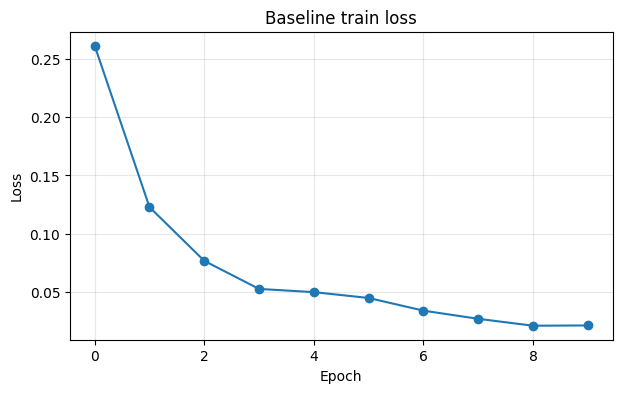

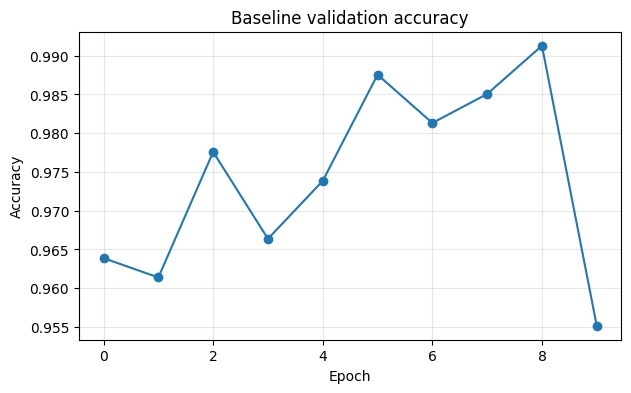

In [35]:
# Train loss
plt.figure(figsize=(7,4))
plt.plot(baseline["train_loss"], marker="o")
plt.title("Baseline train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

# Val accuracy
plt.figure(figsize=(7,4))
plt.plot(baseline["val_acc"], marker="o")
plt.title("Baseline validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.show()

More exps...

In [37]:
nmels_results = []
for nm in [20, 40, 80]:
    res = run_experiment(
        n_mels=nm,
        groups=1,
        epochs=10,
        batch_size=128,
        lr=1e-3,
        num_workers=2,
        data_root="../../data",
    )
    nmels_results.append(res)

Experiment: n_mels=20, groups=1, device=cuda
Sizes: train=6358, val=803, test=824
Params: 26,338
FLOPs: 1176320
Epoch 01/10 | loss=0.2794 | val_acc=0.9377 | time=23.31s
Epoch 02/10 | loss=0.1274 | val_acc=0.9527 | time=20.91s
Epoch 03/10 | loss=0.0828 | val_acc=0.9689 | time=22.75s
Epoch 04/10 | loss=0.0634 | val_acc=0.9851 | time=22.18s
Epoch 05/10 | loss=0.0492 | val_acc=0.9875 | time=20.87s
Epoch 06/10 | loss=0.0369 | val_acc=0.9875 | time=21.89s
Epoch 07/10 | loss=0.0331 | val_acc=0.9813 | time=21.40s
Epoch 08/10 | loss=0.0247 | val_acc=0.9925 | time=21.46s
Epoch 09/10 | loss=0.0243 | val_acc=0.9851 | time=22.03s
Epoch 10/10 | loss=0.0267 | val_acc=0.9913 | time=20.80s
Test accuracy: 0.9915
Experiment: n_mels=40, groups=1, device=cuda
Sizes: train=6358, val=803, test=824
Params: 29,538
FLOPs: 1499520
Epoch 01/10 | loss=0.2642 | val_acc=0.9502 | time=20.86s
Epoch 02/10 | loss=0.1130 | val_acc=0.9701 | time=22.00s
Epoch 03/10 | loss=0.0734 | val_acc=0.9801 | time=20.80s
Epoch 04/10 |

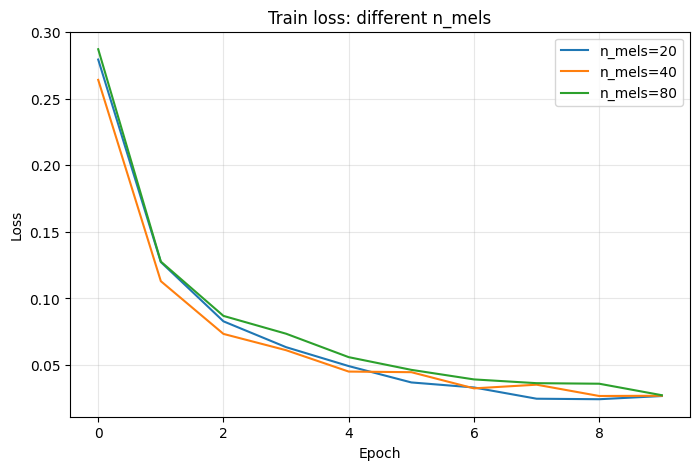

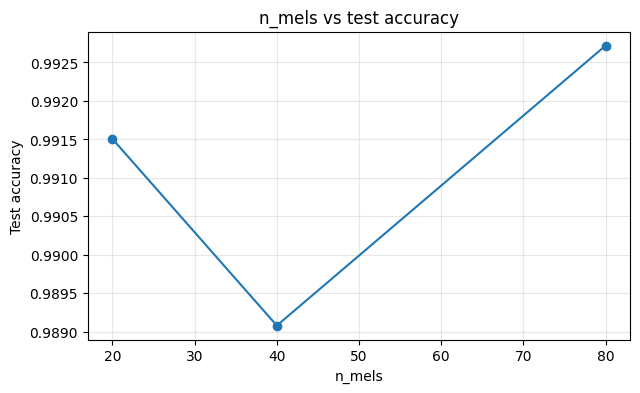

In [38]:
# Train loss curves for different n_mels
plt.figure(figsize=(8,5))
for r in nmels_results:
    plt.plot(r["train_loss"], label=f'n_mels={r["n_mels"]}')
plt.title("Train loss: different n_mels")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# n_mels vs test accuracy
x = [r["n_mels"] for r in nmels_results]
y = [r["test_acc"] for r in nmels_results]

plt.figure(figsize=(7,4))
plt.plot(x, y, marker="o")
plt.title("n_mels vs test accuracy")
plt.xlabel("n_mels")
plt.ylabel("Test accuracy")
plt.grid(alpha=0.3)
plt.show()

В эксперименте с количеством мел-фильтров (n_mels = 20, 40, 80) все модели показали стабильную сходимость: train loss монотонно снижался и к финальным эпохам выходил примерно на один уровень. По итоговой точности на тесте лучшим оказался вариант n_mels=80 (~0.9927). Разница между конфигурациями небольшая (порядка десятых долей процента), но n_mels=80 дает наилучшее качество, поэтому он выбран как базовый вариант для дальнейших экспериментов с параметром groups в Conv1d.

In [40]:
groups_results = []
for g in [2, 4, 8, 16]:
    res = run_experiment(
        n_mels=80,
        groups=g,
        epochs=10,
        batch_size=128,
        lr=1e-3,
        num_workers=2,
        data_root="../../data",
    )
    groups_results.append(res)

Experiment: n_mels=80, groups=2, device=cuda
Sizes: train=6358, val=803, test=824
Params: 18,274
FLOPs: 1089920
Epoch 01/10 | loss=0.3424 | val_acc=0.9315 | time=20.89s
Epoch 02/10 | loss=0.1598 | val_acc=0.9527 | time=22.39s
Epoch 03/10 | loss=0.1055 | val_acc=0.7422 | time=21.71s
Epoch 04/10 | loss=0.0821 | val_acc=0.9253 | time=21.41s
Epoch 05/10 | loss=0.0614 | val_acc=0.9813 | time=23.42s
Epoch 06/10 | loss=0.0544 | val_acc=0.9875 | time=21.54s
Epoch 07/10 | loss=0.0486 | val_acc=0.9726 | time=21.59s
Epoch 08/10 | loss=0.0427 | val_acc=0.9813 | time=22.27s
Epoch 09/10 | loss=0.0348 | val_acc=0.9826 | time=21.02s
Epoch 10/10 | loss=0.0313 | val_acc=0.9763 | time=22.29s
Test accuracy: 0.9794
Experiment: n_mels=80, groups=4, device=cuda
Sizes: train=6358, val=803, test=824
Params: 9,442
FLOPs: 561920
Epoch 01/10 | loss=0.4175 | val_acc=0.8929 | time=22.29s
Epoch 02/10 | loss=0.2159 | val_acc=0.9489 | time=22.05s
Epoch 03/10 | loss=0.1435 | val_acc=0.9564 | time=20.98s
Epoch 04/10 | l

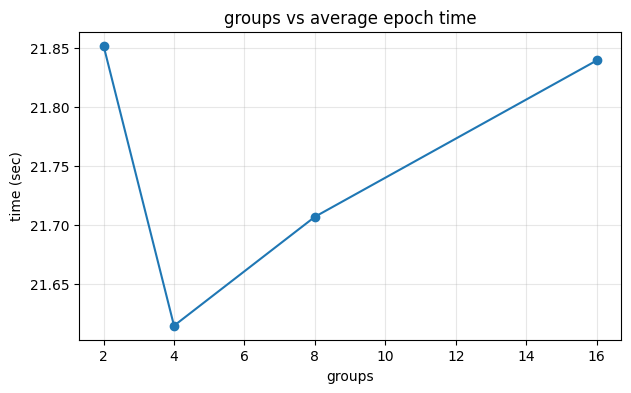

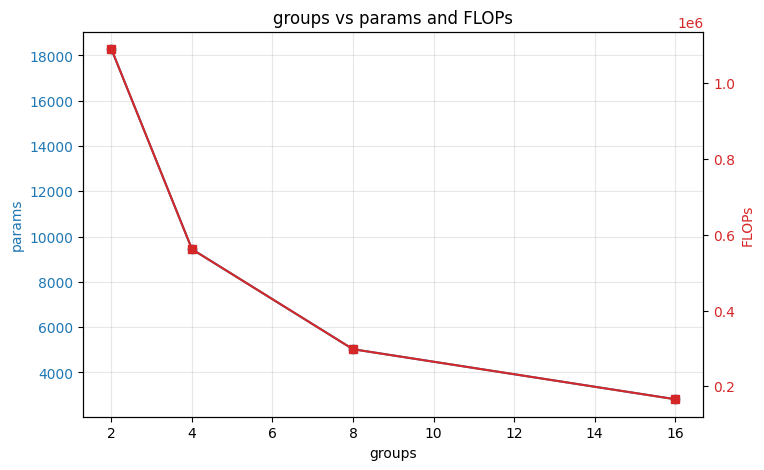

In [41]:
g = [r["groups"] for r in groups_results]
avg_time = [sum(r["epoch_time_sec"]) / len(r["epoch_time_sec"]) for r in groups_results]
params = [r["params"] for r in groups_results]
flops = [r["flops"] if r["flops"] is not None else 0 for r in groups_results]

# groups vs epoch time
plt.figure(figsize=(7,4))
plt.plot(g, avg_time, marker="o")
plt.title("groups vs average epoch time")
plt.xlabel("groups")
plt.ylabel("time (sec)")
plt.grid(alpha=0.3)
plt.show()

# groups vs params/FLOPs
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(g, params, marker="o", color="tab:blue")
ax1.set_xlabel("groups")
ax1.set_ylabel("params", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(g, flops, marker="s", color="tab:red")
ax2.set_ylabel("FLOPs", color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("groups vs params and FLOPs")
plt.show()

Наблюдаем ожидаемое уменьшение вычислительной сложности модели: с ростом groups последовательно снижаются и количество обучаемых параметров, и оценка FLOPs. Это согласуется с теорией grouped convolution, где каждый фильтр обрабатывает только часть входных каналов, что уменьшает число операций.

При этом среднее время эпохи меняется не монотонно и в целом остается близким для всех конфигураций. Такой эффект является нормальным для GPU-обучения компактной модели, поскольку итоговый wall-clock зависит не только от числа операций в свертках, но и от накладных расходов (загрузка данных, извлечение признаков, эффективность конкретных CUDA kernels). В нашем случае минимальное время получено при groups=4, что можно интерпретировать как практический компромисс для данного окружения.

In [42]:
all_results = [baseline] + nmels_results + groups_results
df = pd.DataFrame(all_results)[["n_mels", "groups", "params", "flops", "test_acc"]]
df = df.sort_values(["n_mels", "groups"]).reset_index(drop=True)
df

,n_mels,groups,params,flops,test_acc
0,20,1,26338,1176320,0.991505
1,40,1,29538,1499520,0.989078
2,80,1,35938,2145920,0.957524
3,80,1,35938,2145920,0.992718
4,80,2,18274,1089920,0.979369
5,80,4,9442,561920,0.959951
6,80,8,5026,297920,0.979369
7,80,16,2818,165920,0.966019


In [43]:
all_results = [baseline] + nmels_results + groups_results
df = pd.DataFrame(all_results)[["n_mels", "groups", "params", "flops", "test_acc"]]
df = df.sort_values(["n_mels", "groups"]).reset_index(drop=True)
df

,n_mels,groups,params,flops,test_acc
0,20,1,26338,1176320,0.991505
1,40,1,29538,1499520,0.989078
2,80,1,35938,2145920,0.957524
3,80,1,35938,2145920,0.992718
4,80,2,18274,1089920,0.979369
5,80,4,9442,561920,0.959951
6,80,8,5026,297920,0.979369
7,80,16,2818,165920,0.966019
